### Classification after Clustering with KMeans Clustering
#### Import CSV and Required Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import  matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

df=pd.read_csv('./Data/clustered_data.csv')
df

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth,cluster
0,69,2,0,0,0,58138.0,1617.0,5087,58,635,81,546,120.5,81,88.0,8,10,4,3,0,7,1
1,72,2,0,1,2,46344.0,27.0,4537,38,11,1,6,2.0,1,6.0,1,1,2,2,0,5,0
2,61,2,1,0,0,71613.0,776.0,4736,26,426,49,127,111.0,21,42.0,8,2,10,1,0,4,1
3,42,2,1,1,1,26646.0,53.0,4563,26,11,4,20,10.0,3,5.0,2,0,4,2,0,6,0
4,45,4,1,1,1,58293.0,422.0,4585,94,173,43,118,46.0,27,15.0,5,3,6,5,0,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,59,2,1,1,1,61223.0,1341.0,4805,46,709,43,182,42.0,81,126.5,9,3,4,2,0,5,2
2236,80,4,1,1,3,64014.0,444.0,4443,56,406,0,30,0.0,0,8.0,8,2,5,7,1,7,2
2237,45,2,0,0,0,56981.0,1241.0,4579,91,908,48,217,32.0,12,24.0,2,3,13,1,1,6,1
2238,70,3,1,1,1,69245.0,843.0,4580,8,428,30,214,80.0,30,61.0,6,5,10,2,0,3,1


#### Split X and y

**Why do we split our data?**

Training Dataset is the part of Original Dataset that we use to train our ML model. The model learns on this data by running the algorithm and maps a function F(x) where “x” in the independent variable (inputs) for “y” where “y” is the dependent variable(output).

In [2]:
X=df.iloc[:, :-1]
y=df.iloc[:,-1]

#### Grid Search
**Why do we use Grid Search?**

   GridSearchCV is a technique to search through the best parameter values from the given set of the grid of parameters. It is basically a cross-validation method. the model and the parameters are required to be fed in. Best parameter values are extracted and then the predictions are made.

**Select the best model**

   so here we have some list of the best classification algorithms we imported. Now we will compare each model's score and see which model is performing better than rest of the others

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [4]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
    "AdaBoost Classifier": AdaBoostClassifier(),
    "SVC":SVC()
}

In [5]:
def model_evaluation(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)
    
    modelList=[]
    scoreList=[]
    
    for i in range(len(models.items())):
        model=list(models.values())[i]
        
        model.fit(X_train, y_train)
        y_pred=model.predict(X_test)
        
        score=accuracy_score(y_test, y_pred)
        model_name=list(models.keys())[i]
        print(f"For {model_name}, accuracy score is {score}.")
        modelList.append(model_name)
        scoreList.append(score)
        
    Scores=pd.DataFrame()
    Scores['Model']=modelList
    Scores['Score']=scoreList
    return Scores

In [6]:
# checking reports
help(model_evaluation)

Help on function model_evaluation in module __main__:

model_evaluation(X, y, models)
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost



In [7]:
model_evaluation(X, y, models)

For Random Forest, accuracy score is 0.953125.
For Decision Tree, accuracy score is 0.9285714285714286.
For Gradient Boosting, accuracy score is 0.9598214285714286.
For Logistic Regression, accuracy score is 0.875.
For K-Neighbors Classifier, accuracy score is 0.8325892857142857.
For XGBClassifier, accuracy score is 0.9598214285714286.
For AdaBoost Classifier, accuracy score is 0.9352678571428571.
For SVC, accuracy score is 0.7633928571428571.


,Model,Score
0,Random Forest,0.953125
1,Decision Tree,0.928571
2,Gradient Boosting,0.959821
3,Logistic Regression,0.875000
4,K-Neighbors Classifier,0.832589
5,XGBClassifier,0.959821
6,AdaBoost Classifier,0.935268
7,SVC,0.763393


- **From the report above we can see that the gradient boosting model performed the best, so we will continue training our model using gradient boosting algorithm.**

**Split into Train and test data**

- Do you know why we split the train and test dataset?

 The train test split technique can be used for classification and regression problems to test machine learning algorithms. The procedure takes the given dataset and splits it into two subsets: Training data/train set: it is used to train the algorithm and fit the machine learning model then we have test data/test set which is basically a different data for which we know the values but this data was never shown to the model before. Thus if the model after training is performing good on test set as well then we can say that the Machine Learning model is good.

In [8]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, random_state=1)
X_train

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
104,67,2,1,0,0,87195.0,1097.0,4476,35,217,76,556,50.0,26,38.0,3,11,5,1,0,1
2039,44,2,1,0,0,61416.0,1665.0,4930,25,848,81,323,120.5,61,78.0,10,3,10,1,1,6
1942,49,2,0,1,1,23763.0,42.0,5115,64,22,0,6,6.0,2,6.0,1,0,3,1,0,7
1241,59,4,1,1,3,59062.0,71.0,4693,74,46,1,12,3.0,0,9.0,2,0,3,2,0,4
1723,64,4,0,0,0,82571.0,1686.0,4512,28,861,31,556,62.0,81,79.0,6,5,13,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,59,2,0,1,1,70647.0,1079.0,5070,65,561,81,171,25.0,81,114.0,4,7,13,2,0,2
905,49,2,0,0,0,85072.0,1423.0,4505,94,494,81,391,120.5,11,126.5,3,4,10,1,0,0
1096,68,2,0,1,1,79803.0,868.0,4451,54,574,8,216,21.0,16,33.0,4,3,5,1,0,1
235,51,1,1,1,1,22212.0,69.0,4626,49,5,9,20,6.0,8,21.0,2,0,4,2,0,6


#### Let's do hyperparameter tuning

**And what's it actually?**

A Machine Learning model is defined as a mathematical model with a number of parameters that need to be learned from the data. By training a model with existing data, we are able to fit the model parameters. However, there is another kind of parameter, known as Hyperparameters, that cannot be directly learned from the regular training process. They are usually fixed before the actual training process begins. These parameters express important properties of the model such as its complexity or how fast it should learn.

In [9]:
from sklearn.model_selection import GridSearchCV
params= {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

grid=GridSearchCV(GradientBoostingClassifier(), param_grid=params, cv=5, verbose=2)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=0.8; total time=   1.2s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=0.8; total time=   1.1s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=1.0; total time=   1.2s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=1.0; total time=   1.1s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=2, n_estimators=100, subsample=1.0; total time=   1.1

In [10]:
best_model=GradientBoostingClassifier(n_estimators=150, learning_rate=0.2, max_depth=2, subsample=0.8)
best_model.fit(X_train, y_train)
y_pred=best_model.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Confusion matrix: \n', confusion_matrix(y_test, y_pred))
print('Report: \n', classification_report(y_test, y_pred))

Accuracy:  0.9642857142857143
Confusion matrix: 
 [[237   0   2]
 [  1 134  10]
 [  2   5 169]]
Report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       239
           1       0.96      0.92      0.94       145
           2       0.93      0.96      0.95       176

    accuracy                           0.96       560
   macro avg       0.96      0.96      0.96       560
weighted avg       0.96      0.96      0.96       560



#### Confusion matrix of the model
**What is confusion matrix ?**

The confusion matrix is a matrix used to determine the performance of the classification models for a given set of test data. It can only be determined if the true values for test data are known. The matrix itself can be easily understood, but the related terminologies may be confusing.

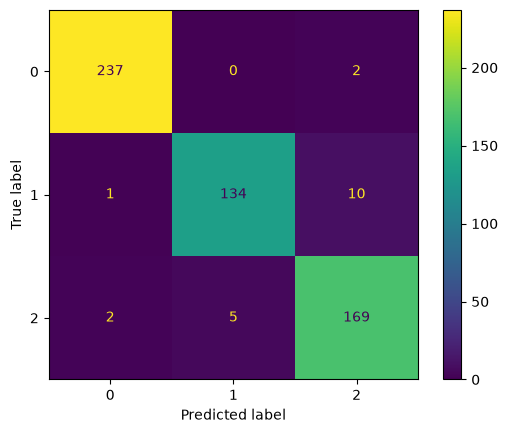

In [11]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

**Reports**

- We can see, that the model performed pretty well.

- we have used logistic regression as it performed well than other models
- We got a good accuracy while predicting the test dataset.


In [12]:
# Dumping the best model into pickle file
import pickle
with open('model.pkl','wb') as model_file:
    pickle.dump(best_model, model_file)
    
print('model.pkl successfully dumped')

model.pkl successfully dumped
